#  [](http://)MRI Reconstruction with Conditioned Diffusion (Cartesian)


In [56]:
!pip install -q fastmri torchmetrics

In [57]:
import torch, numpy as np, matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import glob, h5py

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [58]:
def cartesian_mask(H, W, accel=4):
    mask = np.zeros((H, W), dtype=np.float32)
    center = H//2
    num_low = int(H * 0.08)
    mask[center-num_low//2:center+num_low//2] = 1
    for i in range(H):
        if np.random.rand() < 1/accel:
            mask[i] = 1
    return mask

In [59]:
class FastMRIDataset(Dataset):
    def __init__(self, root):
        self.files = glob.glob(root + '/**/*.h5', recursive=True)
        print('Arquivos:', len(self.files))
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        with h5py.File(self.files[idx], 'r') as f:
            kspace = f['kspace'][()]
            kspace = kspace[np.random.randint(0, kspace.shape[0])]

        kspace = torch.tensor(kspace, dtype=torch.complex64)
        kspace = torch.view_as_real(kspace).float()
        kspace = (kspace - kspace.mean())/(kspace.std()+1e-8)

        Nc,H,W,_ = kspace.shape
        mask_np = cartesian_mask(H,W)
        mask = torch.tensor(mask_np).unsqueeze(0).unsqueeze(-1).repeat(Nc,1,1,2)

        kspace_us = kspace * mask
        return kspace_us, kspace, torch.tensor(mask_np)

In [60]:
def fft2c(img): return torch.fft.fft2(img)
def ifft2c(k): return torch.fft.ifft2(k)

In [61]:
def to_image(k):
    k = torch.view_as_complex(k)
    img = torch.abs(torch.fft.ifft2(k))
    img = torch.sqrt((img**2).sum(dim=1)).unsqueeze(1)
    img = (img - img.min())/(img.max()-img.min()+1e-8)
    return img

In [62]:
T=50
beta=torch.linspace(1e-4,0.02,T).to(device)
alpha=1-beta
alpha_bar=torch.cumprod(alpha,0)

In [63]:
def forward_diffusion(x0,t):
    noise=torch.randn_like(x0)
    a=alpha_bar[t].view(-1,1,1,1)
    return torch.sqrt(a)*x0+torch.sqrt(1-a)*noise, noise

In [64]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(2,64,3,padding=1),nn.ReLU(),
            nn.Conv2d(64,128,3,padding=1),nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),nn.ReLU(),
            nn.Conv2d(128,64,3,padding=1),nn.ReLU(),
            nn.Conv2d(64,1,3,padding=1)
        )
    def forward(self,x,t): return self.net(x)

In [65]:
def loss_fn(model,x0,x_cond):
    t=torch.randint(0,T,(x0.shape[0],),device=device)
    xt,noise=forward_diffusion(x0,t)
    inp=torch.cat([xt,x_cond],dim=1)
    pred=model(inp,t)
    return ((pred-noise)**2).mean()

In [66]:
train_path = '/kaggle/input/datasets/arafatshovon/fastmri-knee-multicoil'

dataset = FastMRIDataset(train_path)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

Arquivos: 194


In [67]:
model=UNet().to(device)
opt=torch.optim.Adam(model.parameters(),1e-4)

data_iter=iter(loader)

for step in range(3000):
    try:
        kus,kgt,mask=next(data_iter)
    except StopIteration:
        data_iter=iter(loader)
        kus,kgt,mask=next(data_iter)

    kus,kgt=kus.to(device),kgt.to(device)
    img_gt=to_image(kgt)
    img_us=to_image(kus)

    loss=loss_fn(model,img_gt,img_us)

    opt.zero_grad(); loss.backward(); opt.step()

    if step%50==0:
        print(step,loss.item())

    if step%500==0:
        torch.save(model.state_dict(),f'/kaggle/working/model_{step}.pth')

0 0.9936261177062988
50 0.6388341188430786
100 0.12138563394546509
150 0.10931932926177979
200 0.05722815543413162
250 0.04118850827217102
300 0.04848343878984451
350 0.04359910264611244
400 0.03566668927669525
450 0.0414845310151577
500 0.028613867238163948
550 0.038071438670158386
600 0.03204501420259476
650 0.09325289726257324
700 0.03988140821456909
750 0.025391528382897377
800 0.0240633562207222
850 0.048296429216861725
900 0.02702854946255684
950 0.019773928448557854
1000 0.2763013243675232
1050 0.06861824542284012
1100 0.037447430193424225
1150 0.08215496689081192
1200 0.042356688529253006
1250 0.016863973811268806
1300 0.027980564162135124
1350 0.023386124521493912
1400 0.07299472391605377
1450 0.03477208688855171
1500 0.02531849406659603
1550 0.43182167410850525
1600 0.026650000363588333
1650 0.02027299627661705
1700 0.03163778781890869
1750 0.01587800122797489
1800 0.029996128752827644
1850 0.015958478674292564
1900 0.02102639526128769
1950 0.045454200357198715
2000 0.0558672

In [68]:
@torch.no_grad()
def sample_conditioned(model,us_img,mask):
    x=torch.randn_like(us_img).to(device)
    mask=mask.unsqueeze(0).unsqueeze(0).float()
    mask=F.interpolate(mask,size=us_img.shape[-2:],mode='nearest').to(device)
    for t in reversed(range(T)):
        t_tensor=torch.tensor([t],device=device)
        inp=torch.cat([x,us_img],dim=1)
        pred=model(inp,t_tensor)
        a=alpha[t]; ab=alpha_bar[t]
        x=(1/torch.sqrt(a))*(x-(1-a)/torch.sqrt(1-ab)*pred)
        k=fft2c(x.squeeze(1))
        kus=fft2c(us_img.squeeze(1))
        k=mask.squeeze(1)*kus+(1-mask.squeeze(1))*k
        x=torch.real(ifft2c(k)).unsqueeze(1)
        if t>0: x+=torch.sqrt(beta[t])*torch.randn_like(x)
    return x

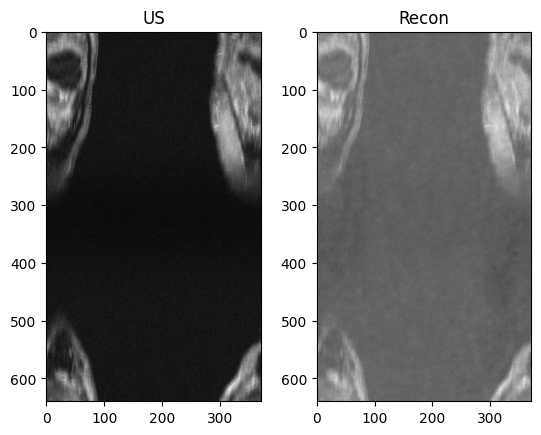

In [69]:
kus,kgt,mask=next(iter(loader))
kus=kus.to(device)
img_us=to_image(kus)
rec=sample_conditioned(model,img_us,mask[0]).cpu()
img_us=img_us.cpu()

plt.subplot(1,2,1); plt.imshow(img_us[0,0],cmap='gray'); plt.title('US')
plt.subplot(1,2,2); plt.imshow(rec[0,0],cmap='gray'); plt.title('Recon'); plt.show()

In [70]:
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

# inicializar métricas (corrigido)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

# listas para média
psnr_vals = []
ssim_vals = []

# avaliar vários exemplos
for i in range(10):

    kus, kgt, mask = next(iter(loader))

    kus = kus.to(device)
    kgt = kgt.to(device)

    # reconstrução
    img_us = to_image(kus)
    img_gt = to_image(kgt)

    rec = sample_conditioned(model, img_us, mask[0])

    # métricas
    psnr_val = psnr_metric(rec, img_gt)
    ssim_val = ssim_metric(rec, img_gt)

    psnr_vals.append(psnr_val.item())
    ssim_vals.append(ssim_val.item())

# médias finais
print(f"PSNR médio: {sum(psnr_vals)/len(psnr_vals):.2f}")
print(f"SSIM médio: {sum(ssim_vals)/len(ssim_vals):.4f}")

PSNR médio: 26.36
SSIM médio: 0.6105
